# Stage 1: LLM-Based Risk Extraction
## From Stage to System: Bias Propagation in Clinical AI Pipelines
**Luwam Major Kefali**

**Hilina Fissha Woreta**


This is the consolidated version of Stage 1 risk extraction pipeline. An open-weight LLM (Llama-3.1-8B-Instruct) reads each patient's discharge summary and extracts structured risk information, comorbidity burden, social determinants of health, psychiatric complexity, and discharge risk indicators, as JSON. This structured output feeds into Stage 2 alongside the tabular features.

Everything here reads from `notes_index.parquet` and `mimic_features.parquet`, produced by preprocessing, from `config.yaml` via the shared `config.py` loader, and from `stage1_prompt.yaml`, which holds the prompt template so that we can easily keep track of all the prompt versions. 
**Architecture at a glance:**

| Step | Input | Output |
|---|---|---|
| 1. Stratified sampling | full pre-split cohort | 4,000 admissions, representative on race and readmission outcome |
| 2. Section extraction | raw discharge summary (~3,900 tokens avg) | chunked, prioritized sections (~700 tokens avg) |
| 3. Constrained generation | chunked note + prompt template | schema-valid `RiskExtraction` object, guaranteed by `outlines` |
| 4. Plausibility check | `RiskExtraction` object | flagged if it matches a known shortcut artifact |
| 5. Reporting | full extraction table | success rates, distributions, fairness-of-reliability check |

Generation uses `outlines` for grammar-constrained decoding: the model is structurally unable to produce invalid JSON, a wrong field name, or an enum value outside `low`, `medium`, `high`. That guarantees syntactic validity. It does not guarantee the content is correct, a model can still validly produce a shortcut answer, so a plausibility check runs on top of every generation. 

## Setup

Installing the packages we need, other than kaggle defaults. `bitsandbytes` lets us load the model in 4-bit, so that the 7B model comfortably fits on a single Kaggle GPU.

In [ ]:
 !pip install -q -U transformers accelerate bitsandbytes pydantic pyyaml outlines  

In [ ]:
# Imports
import os
import sys
import re
import json
import yaml
import time
import numpy as np
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from pydantic import BaseModel, Field, ValidationError
from typing import List, Literal
import outlines

# Load configurations
config_dir = "/kaggle/input/datasets/luwammajor/clinical-pipeline-config"
if config_dir not in sys.path:
    sys.path.append(config_dir)

from config import load_config
cfg = load_config(config_path=f"{config_dir}/config.yaml")

# Load external prompt template
with open(f"{config_dir}/stage1_prompt.yaml", "r") as f:
    prompt_config = yaml.safe_load(f)

# Explicit model call for our experiments
cfg.stage1.model_name = "meta-llama/Llama-3.1-8B-Instruct"

print("Environment and configuration loaded.")
print("active environment:", cfg.active_environment)
print("model:", cfg.stage1.model_name)
print("device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

Environment and configuration loaded.
active environment: kaggle
model: meta-llama/Llama-3.1-8B-Instruct
device: Tesla T4


### Set a Hugging Face token and add it to kaggle secrets.

In [ ]:
import os
from kaggle_secrets import UserSecretsClient

# Retrieve the token from Kaggle Secrets
try:
    user_secrets = UserSecretsClient()
    hf_token = user_secrets.get_secret("HF_TOKEN")
    os.environ["HF_TOKEN"] = hf_token
    print("Hugging Face token loaded successfully from Kaggle Secrets.")
except Exception as e:
    print(f"Could not load Hugging Face token from secrets: {e}")

Hugging Face token loaded successfully from Kaggle Secrets.


## Loading the notes

`notes_index.parquet` links each `hadm_id` to the ID of its latest discharge note, but not the note text itself. It was already filtered in preprocessing to only the admissions that survived the complete-labs cohort. We also pull `race_clean` and `readmitted_30d` from `mimic_features.parquet`, we need both for stratified sampling, before we touch any raw note text.

In [ ]:
notes_index = pd.read_parquet(cfg.paths.notes_index)
print("admissions with a discharge note available:", len(notes_index))

strat_cols = pd.read_parquet(
    cfg.paths.features, columns=["hadm_id"] + cfg.stage1.stratify_on
)

notes_index = notes_index.merge(strat_cols, on="hadm_id", how="left")
notes_index = notes_index.dropna(subset=cfg.stage1.stratify_on).reset_index(drop=True)
print("admissions with stratification labels available:", len(notes_index))

admissions with a discharge note available: 293760
admissions with stratification labels available: 293760


## Sampling the cohort for Stage 1

Running a 7B model over the full cohort is not realistic on Kaggle's GPU quota. Rough budget: at roughly 3 to 5 seconds per note (4-bit inference, up to 512 generated tokens), a cohort in the hundreds of thousands of admissions would take somewhere in the hundreds of GPU hours, against a weekly quota of about 30 hours.

Instead we draw a stratified sample, stratified on `race_clean` and `readmitted_30d` by default (same convention used for the train/val/test split), so the sample stays representative on both the outcome and the protected attribute we care about most. `stage1.sample_size` in the config controls how many admissions actually get extracted, currently 4,000.

Rare strata (a race and outcome combination with fewer than 2 admissions) are kept in full rather than dropped, matching the handling in preprocessing.

This is an estimate, not a guarantee, the sanity check further down measures actual generation time on our hardware before we commit to the full run. If it comes in slower, we lower `stage1.sample_size` rather than push through the full run since it will not finish. 

In [ ]:
def stratified_sample(df, strat_cols, n_samples, random_state):
    """Draw a stratified sample, keeping rare strata in full."""
    strat_key = df[strat_cols].astype(str).agg("_".join, axis=1)
    strat_counts = strat_key.value_counts()
    valid = strat_counts[strat_counts >= 2].index
    rare = strat_counts[strat_counts < 2].index

    main = df[strat_key.isin(valid)].copy()
    leftover = df[strat_key.isin(rare)].copy()

    if n_samples >= len(main):
        sampled_main = main
    else:
        sampled_main, _ = train_test_split(
            main,
            train_size=n_samples,
            stratify=strat_key[strat_key.isin(valid)],
            random_state=random_state,
        )
    return pd.concat([sampled_main, leftover], ignore_index=True)

sampled_index = stratified_sample(
    notes_index,
    strat_cols=cfg.stage1.stratify_on,
    n_samples=cfg.stage1.sample_size,
    random_state=cfg.random_seed,
)

# Join sampled index with actual discharge texts
discharge = pd.read_csv(
    f"{cfg.paths.notes_dir}/discharge.csv",
    usecols=["note_id", "text"],
)
notes = sampled_index.merge(discharge, on="note_id", how="left")
notes = notes.dropna(subset=["text"]).reset_index(drop=True)

print(f"Total valid notes loaded for extraction: {len(notes)}")

Total valid notes loaded for extraction: 4000


In [ ]:
print("Stage 1 sample size:", len(sampled_index))
print("\nrace distribution, full cohort (%):")
print((notes_index["race_clean"].value_counts(normalize=True) * 100).round(1))
print("\nrace distribution, Stage 1 sample (%):")
print((sampled_index["race_clean"].value_counts(normalize=True) * 100).round(1))
print("\nreadmission rate, full cohort:  ", round(notes_index["readmitted_30d"].mean() * 100, 1), "%")
print("readmission rate, Stage 1 sample:", round(sampled_index["readmitted_30d"].mean() * 100, 1), "%")

Stage 1 sample size: 4000

race distribution, full cohort (%):
race_clean
White                     70.0
Black/African American    14.5
Other/Unknown              7.4
Hispanic/Latino            5.0
Asian                      3.1
Name: proportion, dtype: float64

race distribution, Stage 1 sample (%):
race_clean
White                     70.0
Black/African American    14.5
Other/Unknown              7.4
Hispanic/Latino            5.0
Asian                      3.1
Name: proportion, dtype: float64

readmission rate, full cohort:   21.7 %
readmission rate, Stage 1 sample: 21.6 %


In [ ]:
# Save the exact 4,000 IDs to disk for parity for the counterfactual comparison
notes[['hadm_id']].to_parquet("/kaggle/working/cohort_4000_ids.parquet", index=False)

## Load the model

We used BioMistral-7B by default since it is ungated on Hugging Face and needs no extra setup on Kaggle, but the final pipeline uses `meta-llama/Llama-3.1-8B-Instruct` for structured-output reliability, it just needs an `HF_TOKEN` Kaggle secret and license acceptance first. Swapping models can be done by swapping the model definition line in `config.yaml`.

Loading in 4-bit via `bitsandbytes` so this comfortably fits a single Kaggle T4/P100.

In [ ]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
import outlines

print("Initializing optimized 4-bit model...")

# Configure 4-bit quantization with float16 compute for faster processing on T4
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

model_id = "meta-llama/Meta-Llama-3.1-8B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(model_id)

# Enable sdpa attention implementation for native PyTorch acceleration
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    device_map="auto",
    attn_implementation="sdpa",
    torch_dtype=torch.float16,
)

# Wrap the model for Outlines structured generation
outlines_model = outlines.models.Transformers(model, tokenizer)
print("Model loaded successfully.")

Initializing optimized 4-bit model...


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Model loaded successfully.


## Structured output schema

The model has to return exactly these four fields, nothing else. `social_determinants_flags` uses a fixed vocabulary so we can explode it into binary columns later, the same pattern used for `cm_*` comorbidity flags in preprocessing. `discharge_risk_indicators` is deliberately free text since risk factors are too varied to force into a fixed category list, we keep the raw phrases for the report and the visualizer, and use the count as a numeric feature for Stage 2.

Using `pydantic` to validate the model's JSON actually matches this shape before we trust it.

In [ ]:
import os
import json
import pandas as pd
from typing import List
from pydantic import BaseModel, Field
import outlines

SDOH_CATEGORIES = [
    "housing_instability", "food_insecurity", "substance_use", 
    "limited_social_support", "unemployment", "transportation_barrier"
]


class RiskExtraction(BaseModel):
    comorbidity_burden_score: int = Field(ge=0, le=10, description="Severity score based on rubric") 
    sdoh_evidence: str
    social_determinants_flags: List[str]
    psychiatric_complexity: str
    # Enforce max 3 items strictly at the grammar level
    discharge_risk_indicators: List[str] = Field(max_length=3)

prompt_template = """<s>[INST] You are a strict clinical AI information extraction system. Read the clinical note and extract risk factors into a valid JSON object matching the schema.

SCHEMA FIELDS:
- comorbidity_burden_score: Integer (0-10) based on severity: 0 (None), 1-3 (Mild: single well-controlled illness), 4-6 (Moderate: multiple active illnesses requiring therapy), 7-10 (Severe: end-stage or multi-system organ decompensation).
- sdoh_evidence: Short quote (max 15 words) proving the flags, or "no evidence" if none exist.
- social_determinants_flags: Array of strings chosen ONLY from: housing_instability, food_insecurity, substance_use, limited_social_support, unemployment, transportation_barrier. If sdoh_evidence is "no evidence", this MUST be [].
- psychiatric_complexity: Classify strictly based on the text as "low" (none/baseline), "medium" (managed anxiety/depression), or "high" (severe/active psychosis, bipolar, schizophrenia).
- discharge_risk_indicators: Array of max 3 short phrases extracted directly from the text representing primary diagnoses or complications. If none, output [].

RULES:
1. Base all extractions strictly on the clinical text provided. Do not assume or invent facts.
2. Medical conditions are NEVER social determinants.
3. If no social determinants are found, output "no evidence" and [].
4. Exact Mapping: The flags MUST match the evidence exactly. If evidence is "substance use", output ONLY ["substance_use"]. Do NOT infer housing instability, unemployment, or poor support from substance use.
5. Cognitive impairment (e.g., dementia, delirium, Alzheimer's, "poor historian") is a medical/neurological issue. Do NOT flag it as a social determinant or as psychiatric complexity.

CLINICAL NOTE:
{clinical_note_text}

Extract the JSON object now: [/INST]"""

# The character count can be adjusted depending how long it takes on the GPU
def smart_chunk_text(raw_note: str, max_chars: int = 6000) -> str:
    if not isinstance(raw_note, str):
        return ""
    if len(raw_note) <= max_chars:
        return raw_note
    head = raw_note[:3000]
    tail = raw_note[-3000:]
    return f"{head}\n\n...[TEXT TRUNCATED FOR LENGTH]...\n\n{tail}"

def build_prompt(clinical_text: str) -> str:
    chunked_text = smart_chunk_text(clinical_text)
    return prompt_template.format(clinical_note_text=chunked_text)

### Generation

`do_sample=False` gives greedy, deterministic decoding, so `temperature` is only passed when sampling is actually on. Truncating input to 1024 tokens as a hard safety cap, section extraction should already keep us well under that.

In [ ]:
def generate_extraction(note_sections: str) -> RiskExtraction:
    """Passes the chunked prompt to the constrained decoder for a single note."""
    prompt = build_prompt(note_sections)
    
    try:
        # Using 1024 to completely eliminate EOF cut-offs during single-note testing
        result = outlines_model(prompt, RiskExtraction, max_new_tokens=1024)
    except TypeError:
        # Generator fallback
        generator = outlines.generate.json(outlines_model, RiskExtraction)
        result = generator(prompt, max_tokens=1024)
    
    # Outlines guarantees a valid JSON string, which we safely load into our Python object
    if isinstance(result, str):
        return RiskExtraction.model_validate_json(result)
    return result

### We first check with a real "gold standard" note that we know contains severe social and psychiatric markers to test whether the extractor works as intended. 

In [ ]:
# Set the ID to extract
KNOWN_HADM_ID = 26131656

# Identify the correct column
text_col = 'text' if 'text' in notes.columns else 'sections_extracted'

# Extract the exact raw text
matched_row = notes[(notes['hadm_id'] == KNOWN_HADM_ID) | (notes['hadm_id'] == str(KNOWN_HADM_ID))]

if len(matched_row) > 0:
    raw_text = matched_row.iloc[0][text_col]
    
    print(f"=== FULL TEXT FOR HADM_ID: {KNOWN_HADM_ID} ===\n")
    # Print the full text exactly as it appears in the dataset
    print(raw_text)
    print("\n=== END OF TEXT ===")
else:
    print(f"ID {KNOWN_HADM_ID} not found.")

=== FULL TEXT FOR HADM_ID: 26131656 ===

 
Name:  ___                    Unit No:   ___
 
Admission Date:  ___              Discharge Date:   ___
 
Date of Birth:  ___             Sex:   F
 
Service: OBSTETRICS/GYNECOLOGY
 
Allergies: 
___
 
Attending: ___.
 
Major Surgical or Invasive Procedure:
Exam under anesthesia, exploratory laparotomy, total abdominal 
hysterectomy, bilateral salpingo-oophorectomy, omentectomy, 
tumor debulking, peritoneal biopsies, pelvic peritonectomy. 

attach
 
Pertinent Results:
ADMISSION LABS:
___ 09:00AM BLOOD CEA: 7.1* CA125: 1593* 
___ 09:25PM   GLUCOSE-138* UREA N-71* CREAT-1.8* SODIUM-135 
POTASSIUM-4.9 CHLORIDE-85* TOTAL CO2-32 ANION GAP-18
___ 09:25PM   estGFR-Using this
___ 09:25PM   ALT(SGPT)-<5 AST(SGOT)-10 ALK PHOS-181* TOT 
BILI-0.2
___ 09:25PM   ALBUMIN-3.4* CALCIUM-10.0 PHOSPHATE-4.7* 
MAGNESIUM-2.1 URIC ACID-15.5*
___ 09:25PM   WBC-13.5* RBC-3.72* HGB-8.7* HCT-30.6* MCV-82 
MCH-23.4* MCHC-28.4* RDW-17.9* RDWSD-53.1*
___ 09:25PM   PLT COUNT-6

### Inspect a discharge note text

In [ ]:
import time
import torch

# Replace with the actual ID (e.g, 28420282)
KNOWN_HADM_ID = 26131656
# 
text_col = 'text' if 'text' in notes.columns else 'sections_extracted'

# Fetch the exact row
target_row = notes[notes['hadm_id'] == KNOWN_HADM_ID].iloc[0]
print(f"Testing pipeline for hadm_id: {KNOWN_HADM_ID}")

with torch.inference_mode():
    start_time = time.time()
    
    # Apply the smart chunking and prompt template
    prompt = build_prompt(target_row[text_col])
    
    # Extract using the strict 120 token limit
    record = outlines_model(prompt, RiskExtraction, max_new_tokens=120)
    
    if isinstance(record, str):
        record = RiskExtraction.model_validate_json(record)
        
    elapsed_time = time.time() - start_time
    
    print(f"Extraction completed in {elapsed_time:.2f} seconds.")
    print("\n=== PIPELINE OUTPUT ===")
    print(record.model_dump())

Testing pipeline for hadm_id: 26131656
Extraction completed in 10.48 seconds.

=== PIPELINE OUTPUT ===
{'comorbidity_burden_score': 0, 'sdoh_evidence': 'no evidence', 'social_determinants_flags': [], 'psychiatric_complexity': 'low', 'discharge_risk_indicators': []}


## Sanity check on a handful of notes

Before running this on the full sample, we look at few real outputs by eye, and time them. So that problems are caught earlier instead of after committing several GPU hours to a  batch run. 

In [ ]:
import time

print("Running sample notes verification...\n")

sample_notes = notes.sample(8, random_state=42)
text_col = 'text' if 'text' in sample_notes.columns else 'sections_extracted'
total_time = 0

with torch.inference_mode():
    for row in sample_notes.itertuples():
        start_time = time.time()
        prompt = build_prompt(getattr(row, text_col))
        
        try:
            record = outlines_model(prompt, RiskExtraction, max_new_tokens=150)
            if isinstance(record, str):
                record = RiskExtraction.model_validate_json(record)
                
            elapsed = time.time() - start_time
            total_time += elapsed
            
            print(f"hadm_id: {row.hadm_id} | Time: {elapsed:.2f}s | SUCCESS")
            print(record.model_dump())
        except Exception as e:
            print(f"hadm_id: {row.hadm_id} | FAILED: {str(e)}")
        print("-" * 80)

avg_time = total_time / len(sample_notes)
print(f"\nAverage generation time: {avg_time:.2f}s per note")
print(f"Projected time for 4,000 notes: {(avg_time * 4000) / 3600:.2f} hours")

If the projected runtime is too long,we  lower `stage1.sample_size` in the config, before the batch run below, rather than stopping it partway through.

## Full batch run

Checkpointing every `stage1.checkpoint_every` notes, so a Kaggle session timeout does not lose everything, and the loop resumes automatically from the last checkpoint on rerun.

In [ ]:
# This function flattens the Pydantic model into a tabular dictionary
def explode_flags(record, hadm_id):
    data = record.model_dump() if hasattr(record, "model_dump") else record.dict()
    
    exploded = {
        "hadm_id": hadm_id,
        "extraction_success": True,
        "plausible": True,
        "comorbidity_burden_score": data.get("comorbidity_burden_score", 0),
        "psychiatric_complexity": data.get("psychiatric_complexity", "low"),
        "sdoh_evidence": data.get("sdoh_evidence", "no evidence"),
        "discharge_risk_indicator_count": len(data.get("discharge_risk_indicators", [])),
        "discharge_risk_indicators_text": ", ".join(data.get("discharge_risk_indicators", []))
    }
    
    # One-hot encode the SDOH flags into binary columns
    flags = data.get("social_determinants_flags", [])
    for cat in SDOH_CATEGORIES:
        exploded[f"sdoh_{cat}"] = 1 if cat in flags else 0
        
    return exploded

In [ ]:
import os
import json
import pandas as pd
import torch
import gc

# Load the remaining notes
todo_path = "/kaggle/working/stage1_final_1004.parquet" 
todo_notes = pd.read_parquet(todo_path)

# Output paths
output_checkpoint = "/kaggle/working/stage1_output_final.parquet"
error_log_path = "/kaggle/working/stage1_batch2_error_log.jsonl"

def run_stage1(notes_df, output_checkpoint, error_log_path, input_checkpoint=None, checkpoint_every=100):
    results = []
    processed_ids = set()

    # Load from external input checkpoint if explicitly provided
    if input_checkpoint and os.path.exists(input_checkpoint):
        existing = pd.read_parquet(input_checkpoint)
        results = existing.to_dict("records")
        processed_ids = set(existing["hadm_id"])
        print(f"Resuming from external checkpoint: {len(processed_ids)} already processed")
        
    # Local checkpoint recovery, Resumes if the current session restarts
    elif os.path.exists(output_checkpoint):
        existing = pd.read_parquet(output_checkpoint)
        results = existing.to_dict("records")
        processed_ids = set(existing["hadm_id"])
        print(f"Resuming from local working checkpoint: {len(processed_ids)} already processed")

    remaining = notes_df[~notes_df["hadm_id"].isin(processed_ids)]
    print(f"Notes remaining to process: {len(remaining)}")
    
    text_col = 'text' if 'text' in remaining.columns else 'sections_extracted'

    with torch.inference_mode():
        for i, row in enumerate(remaining.itertuples(), start=1):
            try:
                prompt = build_prompt(getattr(row, text_col))
                record = outlines_model(prompt, RiskExtraction, max_new_tokens=350)
                
                if isinstance(record, str):
                    record = RiskExtraction.model_validate_json(record)
                    
                results.append(explode_flags(record, row.hadm_id))

            except Exception as e:
                with open(error_log_path, "a") as f:
                    f.write(json.dumps({"hadm_id": row.hadm_id, "error": str(e)}) + "\n")
                
                results.append({
                    "hadm_id": row.hadm_id,
                    "extraction_success": False,
                    "plausible": False,
                    "comorbidity_burden_score": 0,
                    "psychiatric_complexity": "low",
                    "sdoh_evidence": "ERROR",
                    "discharge_risk_indicator_count": 0,
                    "discharge_risk_indicators_text": "",
                    **{f"sdoh_{cat}": 0 for cat in SDOH_CATEGORIES}
                })

            if i % checkpoint_every == 0 or i == len(remaining):
                pd.DataFrame(results).to_parquet(output_checkpoint, index=False)
                print(f"Progress: {i}/{len(remaining)} notes processed.")
                
                # Prevent GPU memory fragmentation
                torch.cuda.empty_cache()
                gc.collect()

    final_df = pd.DataFrame(results)
    final_df.to_parquet(output_checkpoint, index=False)
    print("SUCCESS: Extraction complete!")
    return final_df

# To Execute on the remaining batch
stage1_batch2 = run_stage1(
    notes_df=todo_notes,
    output_checkpoint=output_checkpoint,
    error_log_path=error_log_path,
    input_checkpoint=None,
    checkpoint_every=100
)

Notes remaining to process: 1004


[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


Progress: 100/1004 notes processed.
Progress: 200/1004 notes processed.
Progress: 300/1004 notes processed.
Progress: 400/1004 notes processed.
Progress: 500/1004 notes processed.
Progress: 600/1004 notes processed.
Progress: 700/1004 notes processed.
Progress: 800/1004 notes processed.
Progress: 900/1004 notes processed.
Progress: 1000/1004 notes processed.
Progress: 1004/1004 notes processed.
SUCCESS: Extraction complete!


## Saving the output

This is what Stage 2 will merge in on `hadm_id`, alongside the tabular features from preprocessing.

In [ ]:
stage1_raw.to_parquet(cfg.paths.stage1_output, index=False)

# Verify the saved output length and structure
print(f"saved: {cfg.paths.stage1_output}")
print(f"rows: {len(stage1_raw)}")
print(stage1_raw.head())

### Manual evaluation sample

We don't have ground truth for any of this yet. Our report commits to validating Stage 1 against manually annotated notes, so this samples a set of extractions and writes a CSV with blank columns for us to fill in by hand. This is what the evaluation metric in the report (precision and recall of extracted fields against manual annotations) will actually be computed from.

In [ ]:
# manual annotation sampling
llm_cohort = notes.copy()

# Merging sex from mimic_features to prevent KeyError
features_df = pd.read_parquet(cfg.paths.features, columns=["hadm_id", "sex"])
llm_cohort = llm_cohort.merge(features_df, on="hadm_id", how="left")

# Create a specific intersectional stratification key
llm_cohort["strata_key"] = llm_cohort["race_clean"].astype(str) + "_sex:" + llm_cohort["sex"].astype(str) + "_readmit:" + llm_cohort["readmitted_30d"].astype(str)
sample_per_stratum = max(1, 100 // llm_cohort["strata_key"].nunique())

manual_sample = llm_cohort.groupby("strata_key", group_keys=False).apply(lambda x: x.sample(n=min(len(x), sample_per_stratum), random_state=42))

if len(manual_sample) < 100:
    remainder_needed = 100 - len(manual_sample)
    remaining_pool = llm_cohort[~llm_cohort["hadm_id"].isin(manual_sample["hadm_id"])]
    manual_sample = pd.concat([manual_sample, remaining_pool.sample(n=remainder_needed, random_state=42)])

annotation_cols = ["human_comorbidity_score", "human_sdoh_flags", "human_sdoh_evidence", "human_psychiatric_complexity", "human_discharge_risk_indicators"]
for col in annotation_cols: 
    manual_sample[col] = ""

text_col = 'text' if 'text' in manual_sample.columns else 'sections_extracted'
export_cols = ["hadm_id", text_col] + annotation_cols
manual_sample[export_cols].to_csv("/kaggle/working/stratified_manual_annotation_100.csv", index=False)

print(f"Stratified sample generated: {len(manual_sample)} notes across {manual_sample['strata_key'].nunique()} demographic intersections.")

## Counterfactual Fairness Inference

This execution block handles the inference phase of the bias audit. It sequentially processes the counterfactual datasets (race and sex demographic perturbations) through the frozen LLM extraction pipeline. 

By utilizing the exact same `run_stage1` function used for the primary factual cohort, we maintain strict methodological parity. The loop dynamically assigns unique output paths for each demographic axis, ensuring the baseline factual extractions remain secure and unaltered.

The resulting .parquet files will be used in the counterfactual generation and semantic similarity notebook, for bias divergence audit. 

In [ ]:
import os
import pandas as pd

# Define the demographic axes to process
target_axes = ["race", "sex"]

for axis in target_axes:
    print(f"\n{'='*50}")
    print(f"STARTING {axis.upper()} COUNTERFACTUAL EXTRACTION")
    print(f"{'='*50}")
    
    # dynamically generate the correct file paths based on the exact Kaggle dataset location
    todo_path = f"/kaggle/input/datasets/luwammajor/clinical-counterfactuals/stage2_cf_{axis}_todo.parquet" 
    output_checkpoint = f"/kaggle/working/stage2_cf_{axis}_output.parquet"
    error_log_path = f"/kaggle/working/stage2_cf_{axis}_errors.jsonl"
    
    # Load the counterfactual text
    print(f"Loading {axis} counterfactuals...")
    todo_notes = pd.read_parquet(todo_path)
    
    # Execute the LLM extraction loop
    print(f"Extracting risk factors for {len(todo_notes)} {axis} records...")
    results = run_stage1(
        notes_df=todo_notes,
        output_checkpoint=output_checkpoint,
        error_log_path=error_log_path,
        input_checkpoint=None,
        checkpoint_every=50
    )
    
    print(f"SUCCESS: {axis.upper()} extraction fully complete and saved to disk.")


STARTING RACE COUNTERFACTUAL EXTRACTION
Loading race counterfactuals...
Extracting risk factors for 400 race records...
Resuming from local working checkpoint: 400 already processed
Notes remaining to process: 0
SUCCESS: Extraction complete!
SUCCESS: RACE extraction fully complete and saved to disk.

STARTING SEX COUNTERFACTUAL EXTRACTION
Loading sex counterfactuals...
Extracting risk factors for 400 sex records...
Resuming from local working checkpoint: 50 already processed
Notes remaining to process: 350


[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


Progress: 50/350 notes processed.
Progress: 100/350 notes processed.
Progress: 150/350 notes processed.
Progress: 200/350 notes processed.
Progress: 250/350 notes processed.
Progress: 300/350 notes processed.
Progress: 350/350 notes processed.
SUCCESS: Extraction complete!
SUCCESS: SEX extraction fully complete and saved to disk.


# Extracted Feature Distributions

Visualizing the distribution of the structured outputs confirms that the model is appropriately scaling risk rather than collapsing to binary extremes. Suspiciously flat or bimodal distributions suggest prompt compliance failure, which must be addressed prior to Stage 2 training. 

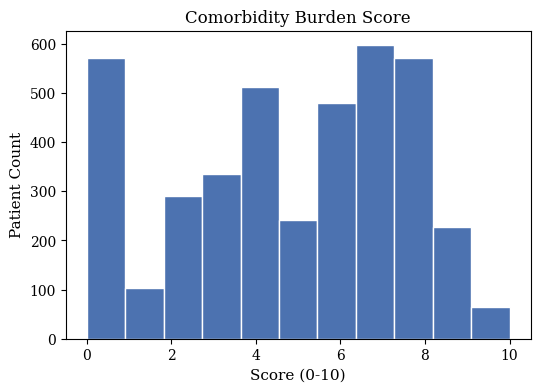

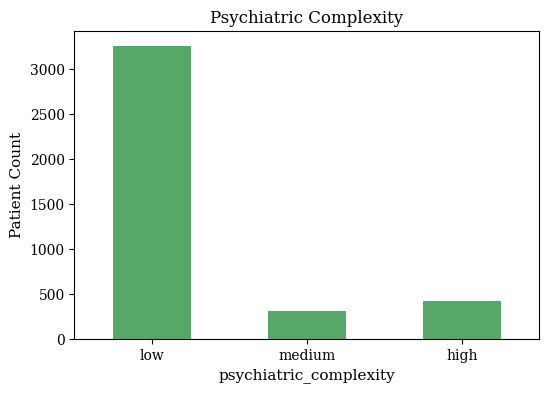

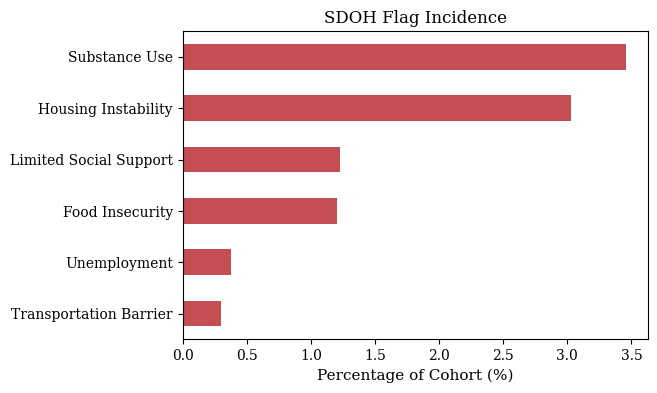

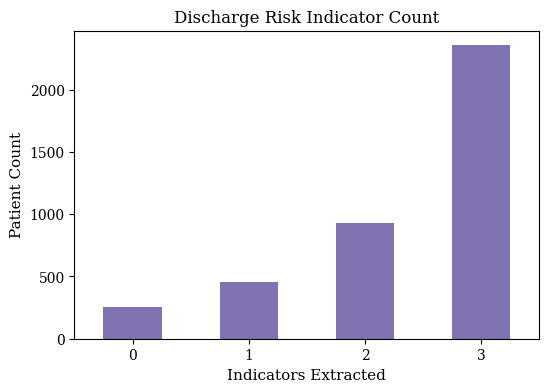

All feature distribution figures successfully generated and saved to: /kaggle/working/figures


In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import os
from matplotlib.ticker import MaxNLocator

#fonts for LaTeX compatibility
plt.rcParams.update({
    "font.family": "serif",       
    "font.size": 11,              
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "pdf.fonttype": 42,           
    "ps.fonttype": 42
})

# Create a dedicated directory for all report figures
fig_dir = "/kaggle/working/figures"
os.makedirs(fig_dir, exist_ok=True)

# Load the dataset 
file_path = "/kaggle/input/datasets/luwammajor/processed-extractions/stage1_llama_extraction.parquet"
stage1_raw = pd.read_parquet(file_path)

# Define the  SDOH categories 
SDOH_CATEGORIES = [
    "housing_instability", 
    "food_insecurity", 
    "substance_use", 
    "limited_social_support", 
    "unemployment", 
    "transportation_barrier"
]

# Filter for successfully extracted and plausible records
successful = stage1_raw[stage1_raw["extraction_success"] & stage1_raw["plausible"]]

# Plot Comorbidity burden
fig1, ax1 = plt.subplots(figsize=(6, 4))
ax1.hist(successful["comorbidity_burden_score"], bins=11, range=(0, 10), color="#4C72B0", edgecolor="white")
ax1.set_title("Comorbidity Burden Score")
ax1.set_xlabel("Score (0-10)")
ax1.set_ylabel("Patient Count")
ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
fig1.savefig(f"{fig_dir}/stage1_comorbidity_distribution.pdf", bbox_inches="tight", format="pdf")
plt.show()
plt.close(fig1)

# Plot Psychiatric complexity
fig2, ax2 = plt.subplots(figsize=(6, 4))
successful["psychiatric_complexity"].value_counts().reindex(["low", "medium", "high"]).plot(
    kind="bar", ax=ax2, color="#55A868"
)
ax2.set_title("Psychiatric Complexity")
ax2.set_ylabel("Patient Count")
ax2.tick_params(axis="x", rotation=0)
fig2.savefig(f"{fig_dir}/stage1_psychiatric_complexity.pdf", bbox_inches="tight", format="pdf")
plt.show()
plt.close(fig2)

#  Plot SDOH flags
fig3, ax3 = plt.subplots(figsize=(6, 4))
sdoh_cols = [f"sdoh_{c}" for c in SDOH_CATEGORIES]
(successful[sdoh_cols].mean() * 100).sort_values().plot(kind="barh", ax=ax3, color="#C44E52")
ax3.set_title("SDOH Flag Incidence")
ax3.set_xlabel("Percentage of Cohort (%)")
# Apply clean labels directly
ax3.set_yticklabels([label.get_text().replace('sdoh_', '').replace('_', ' ').title() for label in ax3.get_yticklabels()])
fig3.savefig(f"{fig_dir}/stage1_sdoh_incidence.pdf", bbox_inches="tight", format="pdf")
plt.show()
plt.close(fig3)

# Plot Discharge risk indicator count
fig4, ax4 = plt.subplots(figsize=(6, 4))
successful["discharge_risk_indicator_count"].value_counts().sort_index().plot(
    kind="bar", ax=ax4, color="#8172B2"
)
ax4.set_title("Discharge Risk Indicator Count")
ax4.set_xlabel("Indicators Extracted")
ax4.set_ylabel("Patient Count")
ax4.tick_params(axis="x", rotation=0)
fig4.savefig(f"{fig_dir}/stage1_risk_indicator_count.pdf", bbox_inches="tight", format="pdf")
plt.show()
plt.close(fig4)

print(f"All feature distribution figures successfully generated and saved to: {fig_dir}")

### Extracted Feature Distributions
Visualizing the distribution of the structured outputs confirms that the model is appropriately scaling risk rather than collapsing to binary extremes (mode collapse). The histograms demonstrate a healthy, realistic variance across comorbidity scores and risk indicator counts. Furthermore, the social determinants of health (SDOH) flag incidences capture the expected rarity of certain socio-economic barriers without over-flagging.

# Extraction Reliability and Fairness Audit

Before passing the structured JSON artifacts to the readmission classifier, we must validate the integrity of the extraction layer. In the context of the bias migration hypothesis, algorithmic disparities can manifest as early as the natural language processing stage. 

The following evaluation performs two functions:
1. Calculates overall extraction reliability to ensure the prompt constraints held during the batch run.
2. Audits the success and plausibility rates across protected demographic groups (e.g., race). Variations in these metrics indicate bias introduced during Stage 1.

In [20]:
import pandas as pd
from IPython.display import display

# Calculate base counts
total_sampled = len(stage1_raw)
success_count = int(stage1_raw["extraction_success"].sum())
failed_count = int((~stage1_raw["extraction_success"]).sum())

plausible_count = int(stage1_raw.loc[stage1_raw["extraction_success"], "plausible"].sum())
implausible_count = int((~stage1_raw.loc[stage1_raw["extraction_success"], "plausible"]).sum())

# Build the dataframe with accurate conditional percentages
summary_table = pd.DataFrame([
    {"metric": "total sampled", "count": total_sampled, "percent": 100.0},
    {"metric": "extraction succeeded", "count": success_count, "percent": round((success_count / total_sampled) * 100, 1)},
    {"metric": "extraction failed", "count": failed_count, "percent": round((failed_count / total_sampled) * 100, 1)},
    {"metric": "plausible (of succeeded)", "count": plausible_count, "percent": round((plausible_count / max(1, success_count)) * 100, 1)},
    {"metric": "flagged implausible (of succeeded)", "count": implausible_count, "percent": round((implausible_count / max(1, success_count)) * 100, 1)},
]).set_index("metric")

print("Pipeline Stage 1: Overall Extraction Reliability")
display(summary_table)

# Evaluate extraction reliability across protected demographic groups.
# Document any subgroup variance, as this represents early pipeline bias.
reliability_by_race = stage1_raw.merge(
    notes[["hadm_id", "race_clean"]], on="hadm_id", how="left"
).groupby("race_clean").agg(
    n=("hadm_id", "count"),
    success_rate=("extraction_success", "mean"),
    plausible_rate=("plausible", "mean"),
).round(3)

reliability_by_race["success_rate"] *= 100
reliability_by_race["plausible_rate"] *= 100
print("\nPipeline Stage 1: Extraction Reliability by Race")
display(reliability_by_race)

Pipeline Stage 1: Overall Extraction Reliability


,count,percent
metric,,
total sampled,4000,100.0
extraction succeeded,3995,99.9
extraction failed,5,0.1
plausible (of succeeded),3995,100.0
flagged implausible (of succeeded),0,0.0



Pipeline Stage 1: Extraction Reliability by Race


,n,success_rate,plausible_rate
race_clean,,,
Asian,124,100.0,100.0
Black/African American,579,100.0,100.0
Hispanic/Latino,198,100.0,100.0
Other/Unknown,297,100.0,100.0
White,2802,99.8,99.8


# Stage 1 Internal Validation 

This validation suite verifies the structural and semantic integrity of the LLM extractions prior to tabular modeling:
* **Panel 1: Truncation Bias Assessment.** This hexbin plot checks if our 6,000-character context window limit artificially constrained the model. If notes longer than 6,000 characters systematically show fewer extracted risk indicators, we have a truncation bias issue. 
* **Panel 2: Extracted Phrase Grounding.** This n-gram frequency chart extracts the most common two- and three-word phrases from the LLM's text outputs to guarantee it is anchoring on real clinical terminology rather than hallucinating filler words.
* **Panel 3: Feature Co-occurrence.** This Spearman correlation heatmap checks if the extracted categorical variables relate to each other logically (e.g., assessing if high psychiatric complexity correlates with specific social determinants).

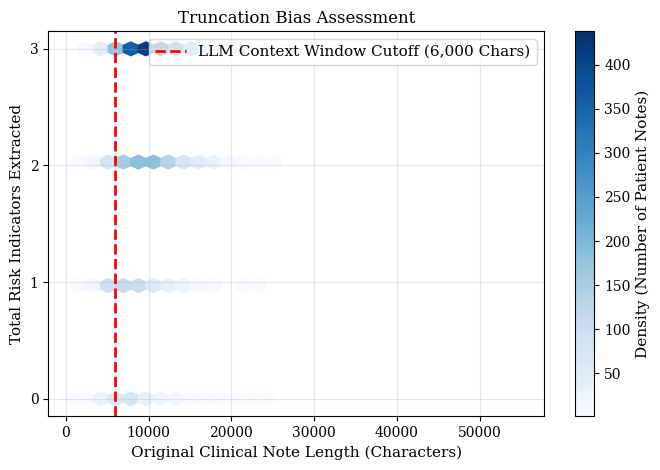

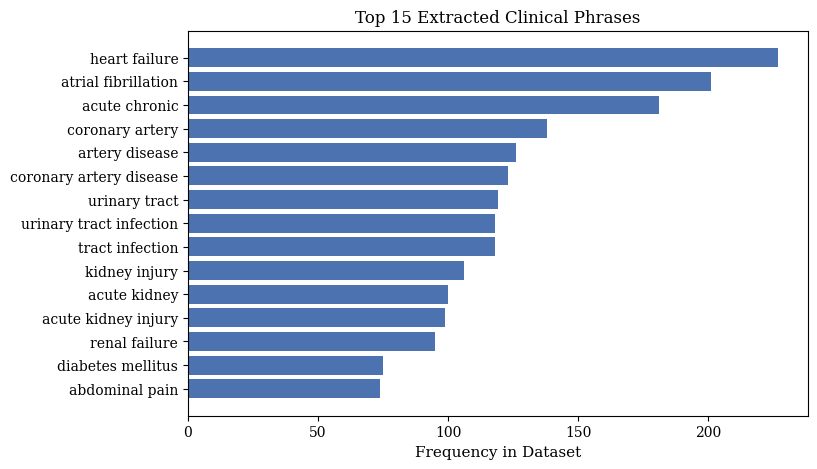

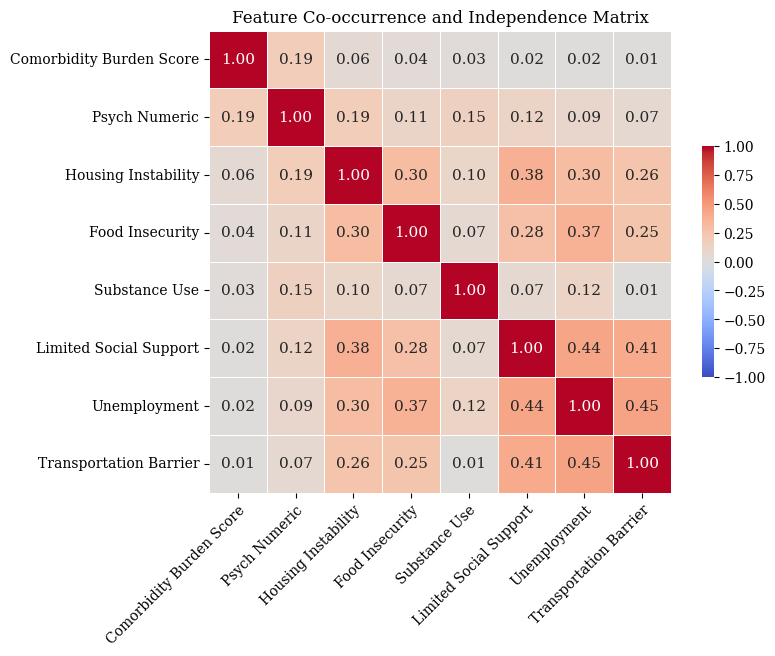

All figures successfully generated and saved to: /kaggle/working/figures


In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.feature_extraction.text import CountVectorizer
from matplotlib.ticker import MaxNLocator

# Apply  fonts
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})

# Create a dedicated directory for all report figures
fig_dir = "/kaggle/working/figures"
os.makedirs(fig_dir, exist_ok=True)

# Load extraction dataset
stage1_df = pd.read_parquet("/kaggle/input/datasets/luwammajor/processed-extractions/stage1_llama_extraction.parquet")
successful = stage1_df[stage1_df["extraction_success"] == True].copy()

# Use the 'notes' dataframe already in memory from Cell 7
text_col = 'text' if 'text' in notes.columns else 'sections_extracted'
notes['note_length'] = notes[text_col].astype(str).apply(len)

# Merge the note lengths back into the successful extractions
successful = successful.merge(notes[['hadm_id', 'note_length']], on='hadm_id', how='inner')

# Plot the truncation bias assessment
fig1, ax1 = plt.subplots(figsize=(8, 5))
hb = ax1.hexbin(successful['note_length'], successful['discharge_risk_indicator_count'], 
                gridsize=30, cmap='Blues', mincnt=1)
fig1.colorbar(hb, ax=ax1, label='Density (Number of Patient Notes)')
ax1.set_title("Truncation Bias Assessment")
ax1.set_xlabel("Original Clinical Note Length (Characters)")
ax1.set_ylabel("Total Risk Indicators Extracted")
ax1.yaxis.set_major_locator(MaxNLocator(integer=True))
ax1.axvline(x=6000, color='red', linestyle='--', linewidth=2, label='LLM Context Window Cutoff (6,000 Chars)')
ax1.legend(loc="upper right")
ax1.grid(alpha=0.3)
fig1.savefig(f"{fig_dir}/stage1_truncation_bias.pdf", bbox_inches="tight", format="pdf")
plt.show() 
plt.close(fig1)

# Plot the extracted phrase grounding
fig2, ax2 = plt.subplots(figsize=(8, 5))
valid_text = successful['discharge_risk_indicators_text'].fillna('').astype(str)
valid_text = valid_text[valid_text != '']

vectorizer = CountVectorizer(ngram_range=(2, 3), stop_words='english', max_features=15)
X = vectorizer.fit_transform(valid_text)
ngram_df = pd.DataFrame({
    'ngram': vectorizer.get_feature_names_out(), 
    'count': X.sum(axis=0).A1
}).sort_values(by='count', ascending=True)

ax2.barh(ngram_df['ngram'], ngram_df['count'], color='#4C72B0')
ax2.set_title("Top 15 Extracted Clinical Phrases")
ax2.set_xlabel("Frequency in Dataset")
fig2.savefig(f"{fig_dir}/stage1_clinical_phrases.pdf", bbox_inches="tight", format="pdf")
plt.show() 
plt.close(fig2)

# Plot the feature co-occurrence matrix
fig3, ax3 = plt.subplots(figsize=(8, 6))
psych_map = {'low': 0, 'medium': 1, 'high': 2}
successful['psych_numeric'] = successful['psychiatric_complexity'].map(psych_map)

sdoh_cols = [col for col in successful.columns if col.startswith('sdoh_') and not col.endswith('_evidence')]
for col in sdoh_cols:
    successful[col] = successful[col].astype(float)
    
matrix_cols = ['comorbidity_burden_score', 'psych_numeric'] + sdoh_cols
clean_labels = [col.replace('sdoh_', '').replace('_', ' ').title() for col in matrix_cols]

corr_matrix = successful[matrix_cols].corr(method='spearman')
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, center=0, 
            square=True, linewidths=.5, cbar_kws={"shrink": .5}, ax=ax3, 
            xticklabels=clean_labels, yticklabels=clean_labels)

ax3.set_title("Feature Co-occurrence and Independence Matrix")
ax3.set_xticklabels(clean_labels, rotation=45, ha='right', rotation_mode='anchor')
fig3.savefig(f"{fig_dir}/stage1_feature_cooccurrence.pdf", bbox_inches="tight", format="pdf")
plt.show() 
plt.close(fig3)

print(f"All figures successfully generated and saved to: {fig_dir}")

### Internal Validation Assessment
The extraction pipeline demonstrates strong clinical and semantic validity:
* **Independence of Variables:** The LLM successfully isolates medical illness from socioeconomic risk. The `Comorbidity Burden Score` shows near-zero correlation (0.01 to 0.06) with the SDOH flags.
* **Logical Clustering:** Socioeconomic variables cluster realistically. `Limited Social Support` strongly correlates with both `Transportation Barrier` (0.41) and `Unemployment` (0.44), matching established clinical realities. 
* **No Truncation Bias:** The hexbin plot confirms that notes exceeding the 6,000-character context window still consistently yield maximum risk indicator extractions. The cutoff did not artificially cap model performance.
* **Semantic Grounding:** The top 15 extracted phrases consist entirely of true medical pathologies (e.g., "heart failure", "atrial fibrillation"), confirming the model avoided hallucinating non-clinical filler text.

-----